# 01 · Análisis por estratos y significancia estadística

**Proyecto:** Buscador semántico híbrido para reportes (GovTech / SUID).
**Alcance de este notebook:** desglose completo de la calidad de recuperación **por
estrato de consulta** y las pruebas estadísticas pareadas que sostienen (o no) las
conclusiones de la escalera de ablación.

## 1. Contexto y objetivos

La escalera de ablación (notebook `Benchmark_Escalera_Ablacion.ipynb`) mostró que la mejor
configuración global es **Híbrido + ontología** (nDCG@10 = 0.936). Una media global, sin
embargo, puede ocultar comportamientos opuestos por tipo de consulta. Aquí:

1. Desglosamos **nDCG@10, MRR@10, Recall@100 y P@10** por los cuatro estratos
   (*entidad_exacta*, *ambigua*, *documento_largo*, *competencias*), comparando las seis
   configuraciones dentro de cada uno (**punto 1** de la entrega).
2. Ejecutamos la **prueba de Wilcoxon pareada** entre Config 4 (Híbrido + ontología) y
   Config 3 (Híbrido sin ontología), con **tamaño del efecto** (Cliff's δ) e intervalos de
   confianza *bootstrap*, con énfasis en *entidad_exacta* (**punto 3**).

**Marco de evaluación (recordatorio honesto).** Es recuperación de información, no
aprendizaje supervisado: el modelo denso está **congelado** (solo inferencia), no hay
partición train/test, y las consultas siguen el protocolo *known-item* (una consulta apunta
a un reporte objetivo conocido). El **valor absoluto** de las métricas no es precisión de
producción; la evidencia está en la **comparación relativa** entre configuraciones.

## 2. Preparación, datos y núcleo de recuperación

### Núcleo de recuperación (idéntico en todos los notebooks de la entrega)

Para que cada notebook sea **autónomo y reproducible**, se define aquí todo el código de recuperación y evaluación: librerías, carga de datos, métricas, índices (BM25 y denso), fusión RRF, detector de entidades, el motor de las cinco configuraciones y la estadística. No se importa nada de `experimentos/lib`.

In [1]:
# --- Librerías y utilidades base ---
import json, sys, time, math, re, unicodedata, warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from scipy import stats as sp_stats

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.grid": True, "grid.alpha": 0.25})

# Localiza la raíz del proyecto y la carpeta de datos del experimento.
RAIZ = Path.cwd()
if RAIZ.name == "notebooks":
    RAIZ = RAIZ.parent
EXP = RAIZ / "experimentos"
cfg = yaml.safe_load((EXP / "config.yaml").read_text(encoding="utf-8"))
SEMILLA = cfg["evaluacion"]["semilla"]
np.random.seed(SEMILLA)
print("Encoder:", cfg["encoder"]["tipo"], "→", cfg["encoder"]["modelo_st"])
print("BM25:", cfg["bm25"], "| RRF k =", cfg["fusion"]["k_rrf"], "| realce λ =", cfg["realce"]["lambda"])

Encoder: sentence-transformer → jinaai/jina-embeddings-v3
BM25: {'k1': 1.5, 'b': 0.75} | RRF k = 60 | realce λ = 0.2


In [2]:
# --- Carga de datos ya construidos por el pipeline reproducible (make all) ---
# El corpus lo produce experimentos/preprocess_corpus.py; las consultas y juicios,
# experimentos/generar_consultas.py (protocolo known-item). Aquí solo se leen.
def cargar_jsonl(ruta):
    return [json.loads(l) for l in Path(ruta).read_text(encoding="utf-8").splitlines() if l.strip()]

docs      = cargar_jsonl(EXP / cfg["rutas"]["corpus"])
consultas = cargar_jsonl(EXP / cfg["rutas"]["consultas"])
qrels     = {r["id"]: r["relevancia"] for r in cargar_jsonl(EXP / cfg["rutas"]["qrels"])}
ontologia = yaml.safe_load((EXP / cfg["rutas"]["ontologia"]).read_text(encoding="utf-8"))

tiene_gold = lambda q: any(g > 0 for g in q.values())
con_gold = [c for c in consultas if tiene_gold(qrels.get(c["id"], {}))]
estratos = sorted({c["estrato"] for c in consultas})
print(f"{len(docs)} documentos | {len(consultas)} consultas | {len(con_gold)} con gold")
print("Estratos:", {e: sum(1 for c in consultas if c['estrato']==e) for e in estratos})

17 documentos | 51 consultas | 40 con gold
Estratos: {'ambigua': 13, 'competencias': 11, 'documento_largo': 10, 'entidad_exacta': 17}


In [3]:
# --- Métricas de recuperación (nDCG, Recall, MRR, P@k, AP) con ganancia exponencial ---
def _grado(qrel, doc): return float(qrel.get(doc, 0.0))

def dcg(ranking, qrel, k):
    return sum((2.0**_grado(qrel, d) - 1.0) / math.log2(i + 1)
               for i, d in enumerate(ranking[:k], 1) if _grado(qrel, d) > 0)

def ndcg(ranking, qrel, k):
    ideal = sorted((g for g in qrel.values() if g > 0), reverse=True)
    idcg = sum((2.0**g - 1.0) / math.log2(i + 1) for i, g in enumerate(ideal[:k], 1))
    return 0.0 if idcg == 0 else dcg(ranking, qrel, k) / idcg

def recall(ranking, qrel, k):
    rel = {d for d, g in qrel.items() if g > 0}
    return 0.0 if not rel else sum(1 for d in ranking[:k] if d in rel) / len(rel)

def mrr(ranking, qrel, k):
    for i, d in enumerate(ranking[:k], 1):
        if _grado(qrel, d) > 0: return 1.0 / i
    return 0.0

def precision(ranking, qrel, k):
    return 0.0 if k == 0 else sum(1 for d in ranking[:k] if _grado(qrel, d) > 0) / k

def average_precision(ranking, qrel, k):
    rel = {d for d, g in qrel.items() if g > 0}
    if not rel: return 0.0
    ac, s = 0, 0.0
    for i, d in enumerate(ranking[:k], 1):
        if d in rel: ac += 1; s += ac / i
    return s / min(len(rel), k)

def metricas_consulta(rank, qrel):
    return {"ndcg@10": ndcg(rank, qrel, 10), "mrr@10": mrr(rank, qrel, 10),
            "recall@100": recall(rank, qrel, 100), "p@10": precision(rank, qrel, 10),
            "ap@100": average_precision(rank, qrel, 100)}

# auto-test mínimo
assert ndcg(["a","b"], {"a":1.0}, 10) == 1.0 and mrr(["b","a"], {"a":1.0}, 10) == 0.5
print("Métricas listas (auto-test OK).")

Métricas listas (auto-test OK).


In [4]:
# --- Núcleo de recuperación: BM25, codificador denso, RRF, detector y motor ---
_STOP = {"el","la","los","las","un","una","unos","unas","de","del","a","ante","con","en","para",
         "por","que","y","o","u","se","su","sus","lo","al","es","son","como","mas","pero","sin",
         "sobre","entre","cada","ya","cuando","donde","cual","quien","cuanto","muy","este","esta","estos"}

def tokenizar_es(texto):
    "Minúsculas, sin tildes, sin puntuación ni stopwords."
    texto = unicodedata.normalize("NFKD", texto.lower())
    texto = "".join(c for c in texto if not unicodedata.combining(c))
    return [t for t in re.findall(r"[a-z0-9]+", texto) if t not in _STOP and len(t) > 1]

class BM25Index:
    "BM25 clásico desde cero, con analizador en español."
    def __init__(self, k1=1.5, b=0.75): self.k1, self.b = k1, b
    def indexar(self, ids, textos):
        self._ids = list(ids); self._tf = [Counter(tokenizar_es(t)) for t in textos]
        self._len = [sum(c.values()) for c in self._tf]
        self._avg = (sum(self._len)/len(self._len)) if self._len else 0.0
        df = Counter()
        for c in self._tf: df.update(c.keys())
        n = len(self._tf); self._idf = {t: math.log(1+(n-d+0.5)/(d+0.5)) for t, d in df.items()}
        return self
    def buscar(self, q):
        qt = tokenizar_es(q); s = np.zeros(len(self._ids))
        for i, tf in enumerate(self._tf):
            acc = 0.0
            for t in qt:
                if t in tf:
                    f = tf[t]; den = f + self.k1*(1-self.b+self.b*self._len[i]/(self._avg or 1))
                    acc += self._idf.get(t, 0.0)*f*(self.k1+1)/den
            s[i] = acc
        return [(self._ids[i], float(s[i])) for i in np.argsort(-s)]

def _l2(m):
    n = np.linalg.norm(m, axis=1, keepdims=True); n[n == 0] = 1.0
    return m / n

class SentenceTransformerEncoder:
    "Codificador denso real (jina-embeddings-v3), congelado; solo inferencia."
    def __init__(self, modelo, truncar_dim=None):
        from transformers import PreTrainedModel
        if not hasattr(PreTrainedModel, "all_tied_weights_keys"):
            PreTrainedModel.all_tied_weights_keys = {}      # shim compat. transformers 5.x
        from sentence_transformers import SentenceTransformer
        self._m = SentenceTransformer(modelo, trust_remote_code=True)
        self._tr = truncar_dim
        self.nombre = modelo.split("/")[-1] + (f"-mrl{truncar_dim}" if truncar_dim else "")
        self.dim = truncar_dim or self._m.get_sentence_embedding_dimension()
    def encode(self, textos):
        v = self._m.encode(list(textos), convert_to_numpy=True, normalize_embeddings=False).astype(np.float32)
        if self._tr: v = v[:, :self._tr]
        return _l2(v)

class LSAEncoder:
    "Fallback offline determinista (TF-IDF + SVD) si el modelo real no está disponible."
    def __init__(self, n_comp=128, semilla=42):
        from sklearn.feature_extraction.text import TfidfVectorizer
        self.nombre = f"lsa-{n_comp}"; self._nc = n_comp; self._sem = semilla; self.dim = n_comp
        self._tfidf = TfidfVectorizer(analyzer="word", ngram_range=(1,2), min_df=1,
                                      sublinear_tf=True, strip_accents="unicode", lowercase=True)
        self._svd = None
    def fit(self, textos):
        from sklearn.decomposition import TruncatedSVD
        X = self._tfidf.fit_transform(textos)
        nc = max(min(self._nc, X.shape[1]-1, X.shape[0]-1), 2)
        self._svd = TruncatedSVD(n_components=nc, random_state=self._sem).fit(X); self.dim = nc
        return self
    def encode(self, textos):
        return _l2(self._svd.transform(self._tfidf.transform(textos)).astype(np.float32))

def construir_encoder(cfg, textos_fit):
    if cfg["encoder"]["tipo"] == "sentence-transformer":
        try:
            enc = SentenceTransformerEncoder(cfg["encoder"]["modelo_st"])
            print("Encoder real:", enc.nombre, "| dim", enc.dim); return enc
        except Exception as e:
            print("Modelo real no disponible (", type(e).__name__, ") → fallback LSA")
    enc = LSAEncoder(cfg["encoder"]["lsa_componentes"]).fit(textos_fit)
    print("Encoder LSA:", enc.nombre, "| dim", enc.dim); return enc

class DenseIndex:
    "Índice denso por coseno (producto interno sobre vectores normalizados)."
    def __init__(self, encoder): self.encoder = encoder
    def indexar(self, ids, textos):
        self._ids = list(ids); self._mat = self.encoder.encode(textos); return self
    def buscar(self, q):
        qv = self.encoder.encode([q])[0]; s = self._mat @ qv
        return [(self._ids[i], float(s[i])) for i in np.argsort(-s)]

def _norm(s):
    s = unicodedata.normalize("NFKD", s.lower())
    return "".join(c for c in s if not unicodedata.combining(c))

def rrf(a, b, k=60):
    "Reciprocal Rank Fusion con orden y desempate deterministas por doc_id."
    ra = {d: i+1 for i, (d, _) in enumerate(a)}; rb = {d: i+1 for i, (d, _) in enumerate(b)}
    ds = [d for d, _ in a] + [d for d, _ in b if d not in ra]; big = len(ds)+k+1
    fus = {d: 1.0/(k+ra.get(d, big)) + 1.0/(k+rb.get(d, big)) for d in ds}
    return sorted(ds, key=lambda d: (-fus[d], d)), fus

class DetectorEntidades:
    "Detecta clases de la ontología y nombres propios mencionados en la consulta."
    def __init__(self, ontologia):
        self._term = []
        for clase, cuerpo in ontologia.get("clases", {}).items():
            for t in [clase, *cuerpo.get("sinonimos", [])]:
                self._term.append((_norm(t), clase))
        self._pat = re.compile(r"\b[A-ZÁÉÍÓÚÑ][a-záéíóúñ]{2,}\b")
    def clases_en(self, q):
        cq = _norm(q); return {c for t, c in self._term if t and t in cq}
    def tiene_nombre_propio(self, q):
        toks = self._pat.findall(q)
        if not toks: return False
        primera = q.strip().split()[:1]
        cand = [t for t in toks if not (primera and t == primera[0])]
        return any(_norm(t) not in {tt for tt, _ in self._term} for t in cand)

CONFIGS = {1:"Denso puro", 2:"Denso + ontología", 3:"Híbrido (sin ontología)",
           4:"Híbrido + ontología", 5:"Híbrido + ontología + realce"}
NOMBRE_BM25 = "BM25 (referencia léxica)"; CONFIG_BM25 = 0

class MotorRecuperacion:
    "Construye los 6 índices una sola vez y responde cualquier configuración."
    def __init__(self, docs, encoder, ontologia, k1, b, k_rrf, lambda_realce):
        self.doc_ids = [d["id"] for d in docs]; self.k_rrf = k_rrf; self.lam = lambda_realce
        self.det = DetectorEntidades(ontologia)
        self.ent = {d["id"]: set(d["metadatos_ontologia"].get("entidades_principales", [])) for d in docs}
        self.esnp = {d["id"]: bool(d.get("nombre_propio_buscable", False)) for d in docs}
        desc = [d["descripcion"] for d in docs]; onto = [d["texto_indexable"] for d in docs]
        self.bm_desc = BM25Index(k1, b).indexar(self.doc_ids, desc)
        self.bm_onto = BM25Index(k1, b).indexar(self.doc_ids, onto)
        self.dn_desc = DenseIndex(encoder).indexar(self.doc_ids, desc)
        self.dn_onto = DenseIndex(encoder).indexar(self.doc_ids, onto)
    def indicador(self, q, doc_id):
        "1 si la consulta y el documento comparten entidad (o ambos son de nombre propio)."
        if self.det.clases_en(q) & self.ent.get(doc_id, set()): return 1
        if self.det.tiene_nombre_propio(q) and self.esnp.get(doc_id): return 1
        return 0
    def fusion_onto(self, q):
        "Devuelve (orden, dict de scores RRF) del híbrido+ontología (config 4)."
        return rrf(self.bm_onto.buscar(q), self.dn_onto.buscar(q), self.k_rrf)
    def recuperar(self, config, q):
        if config == CONFIG_BM25: return [d for d, _ in self.bm_desc.buscar(q)]
        if config == 1: return [d for d, _ in self.dn_desc.buscar(q)]
        if config == 2: return [d for d, _ in self.dn_onto.buscar(q)]
        if config == 3: return rrf(self.bm_desc.buscar(q), self.dn_desc.buscar(q), self.k_rrf)[0]
        if config == 4: return self.fusion_onto(q)[0]
        if config == 5:
            _, fus = self.fusion_onto(q)
            final = {d: s*(1 + self.lam*self.indicador(q, d)) for d, s in fus.items()}
            return sorted(final, key=lambda d: (-final[d], d))
        raise ValueError(config)

textos_fit = [d["texto_indexable"] for d in docs] + [d["descripcion"] for d in docs]
encoder = construir_encoder(cfg, textos_fit)
motor = MotorRecuperacion(docs, encoder, ontologia, cfg["bm25"]["k1"], cfg["bm25"]["b"],
                          cfg["fusion"]["k_rrf"], cfg["realce"]["lambda"])
print("Motor construido (BM25×2, denso×2).")

Encoder real: jina-embeddings-v3 | dim 1024


Motor construido (BM25×2, denso×2).


In [5]:
# --- Estadística: Wilcoxon pareado y bootstrap; tamaño del efecto ---
def wilcoxon_pareado(a, b):
    "Wilcoxon signed-rank pareado (a-b): p-valor y media de la diferencia."
    a, b = np.asarray(a, float), np.asarray(b, float); dif = a - b
    if np.allclose(dif, 0):
        return {"p_valor": None, "media_dif": 0.0, "n": len(a), "nota": "diferencias nulas"}
    try:
        est, p = sp_stats.wilcoxon(a, b, zero_method="wilcox")
        return {"estadistico": float(est), "p_valor": float(p), "media_dif": float(dif.mean()), "n": len(a)}
    except ValueError as e:
        return {"p_valor": None, "media_dif": float(dif.mean()), "n": len(a), "nota": str(e)}

def bootstrap_ic(vals, n=2000, alpha=0.05, semilla=SEMILLA):
    "IC percentil por bootstrap para la media."
    v = np.asarray(vals, float)
    if len(v) == 0: return {"media": None, "ic_bajo": None, "ic_alto": None, "n": 0}
    rng = np.random.default_rng(semilla)
    m = np.array([rng.choice(v, size=len(v), replace=True).mean() for _ in range(n)])
    return {"media": float(v.mean()), "ic_bajo": float(np.percentile(m, 100*alpha/2)),
            "ic_alto": float(np.percentile(m, 100*(1-alpha/2))), "n": len(v)}

def cliffs_delta(a, b):
    "Tamaño del efecto no paramétrico Cliff's delta (a vs b)."
    a, b = np.asarray(a, float), np.asarray(b, float)
    if len(a) == 0 or len(b) == 0: return 0.0
    gt = sum((x > y) for x in a for y in b); lt = sum((x < y) for x in a for y in b)
    return (gt - lt) / (len(a)*len(b))

def magnitud_cliff(d):
    ad = abs(d)
    return ("insignificante" if ad < 0.147 else "pequeño" if ad < 0.33
            else "mediano" if ad < 0.474 else "grande")
print("Estadística lista (Wilcoxon, bootstrap, Cliff's delta).")

Estadística lista (Wilcoxon, bootstrap, Cliff's delta).


## 3. Ejecución de las seis configuraciones

**Descripción técnica.** Para cada configuración y cada consulta se calcula el ranking y
las métricas por consulta (solo en las que tienen documento relevante en la v1). Guardamos
los valores por consulta para poder agregarlos por estrato y correr pruebas pareadas.

In [6]:
configuraciones = [(CONFIG_BM25, NOMBRE_BM25)] + list(CONFIGS.items())
orden_cfg = [n for _, n in configuraciones]
METRICAS = ["ndcg@10", "mrr@10", "recall@100", "p@10", "ap@100"]

por_consulta, latencias = {}, {}
for num, nombre in configuraciones:
    por_consulta[nombre], latencias[nombre] = {}, []
    for c in consultas:
        t0 = time.perf_counter()
        rank = motor.recuperar(num, c["texto"])
        latencias[nombre].append((time.perf_counter() - t0) * 1000)
        if tiene_gold(qrels.get(c["id"], {})):
            por_consulta[nombre][c["id"]] = metricas_consulta(rank, qrels[c["id"]])

# índices de consulta por estrato (solo con gold)
ids_estrato = {e: [c["id"] for c in con_gold if c["estrato"] == e] for e in estratos}
ids_estrato = {e: v for e, v in ids_estrato.items() if v}     # descarta estratos sin gold
ids_global = [c["id"] for c in con_gold]

def agrega(nombre, ids, metrica):
    vals = [por_consulta[nombre][i][metrica] for i in ids if i in por_consulta[nombre]]
    return float(np.mean(vals)) if vals else float("nan")
def serie(nombre, ids, metrica="ndcg@10"):
    return [por_consulta[nombre][i][metrica] for i in ids if i in por_consulta[nombre]]

print("Estratos con juicios:", list(ids_estrato))
print("Estrato SIN cobertura en v1 (vacío de cobertura):",
      sorted({c['estrato'] for c in consultas if not tiene_gold(qrels.get(c['id'],{}))}))

Estratos con juicios: ['ambigua', 'documento_largo', 'entidad_exacta']
Estrato SIN cobertura en v1 (vacío de cobertura): ['competencias']


## 4. Tablas completas de resultados por estrato

**Descripción técnica.** Una tabla por estrato: filas = configuraciones, columnas =
métricas. Se resalta el máximo por columna.

In [7]:
def tabla_estrato(ids):
    df = pd.DataFrame({m: {n: agrega(n, ids, m) for n in orden_cfg} for m in
                       ["ndcg@10","mrr@10","recall@100","p@10"]})
    return df.loc[orden_cfg]

tablas = {e: tabla_estrato(ids_estrato[e]) for e in ids_estrato}
tablas["GLOBAL"] = tabla_estrato(ids_global)
for e, df in tablas.items():
    print(f"\n================  Estrato: {e}  ({len(ids_estrato.get(e, ids_global))} consultas)  ================")
    display(df.style.highlight_max(axis=0, color="#c9f0c9").format("{:.3f}"))


================  Estrato: ambigua  (13 consultas)  ================


,ndcg@10,mrr@10,recall@100,p@10
BM25 (referencia léxica),0.781,0.739,1.000,0.092
Denso puro,0.919,0.894,1.000,0.100
Denso + ontología,0.928,0.904,1.000,0.100
Híbrido (sin ontología),0.835,0.783,1.000,0.100
Híbrido + ontología,0.923,0.897,1.000,0.100
Híbrido + ontología + realce,0.923,0.897,1.000,0.100



================  Estrato: documento_largo  (10 consultas)  ================


,ndcg@10,mrr@10,recall@100,p@10
BM25 (referencia léxica),0.884,0.883,1.000,0.130
Denso puro,0.837,0.817,1.000,0.130
Denso + ontología,0.888,0.883,1.000,0.130
Híbrido (sin ontología),0.896,0.900,1.000,0.130
Híbrido + ontología,0.884,0.883,1.000,0.130
Híbrido + ontología + realce,0.819,0.800,1.000,0.130



================  Estrato: entidad_exacta  (17 consultas)  ================


,ndcg@10,mrr@10,recall@100,p@10
BM25 (referencia léxica),0.866,0.882,1.000,0.118
Denso puro,0.861,0.819,1.000,0.124
Denso + ontología,0.927,0.902,1.000,0.124
Híbrido (sin ontología),0.900,0.902,1.000,0.124
Híbrido + ontología,0.976,0.971,1.000,0.124
Híbrido + ontología + realce,0.957,0.948,1.000,0.124



================  Estrato: GLOBAL  (40 consultas)  ================


,ndcg@10,mrr@10,recall@100,p@10
BM25 (referencia léxica),0.843,0.836,1.000,0.113
Denso puro,0.874,0.843,1.000,0.117
Denso + ontología,0.917,0.898,1.000,0.117
Híbrido (sin ontología),0.878,0.863,1.000,0.117
Híbrido + ontología,0.936,0.925,1.000,0.117
Híbrido + ontología + realce,0.911,0.894,1.000,0.117


## 5. Visualizaciones

### 5.1 Heatmap nDCG@10 (configuración × estrato)

**Interpretación de resultados.** El estrato *entidad_exacta* es donde el híbrido+ontología
despega; *ambigua* y *documento_largo* son más planos. La lectura clave es dónde cada
peldaño aporta.

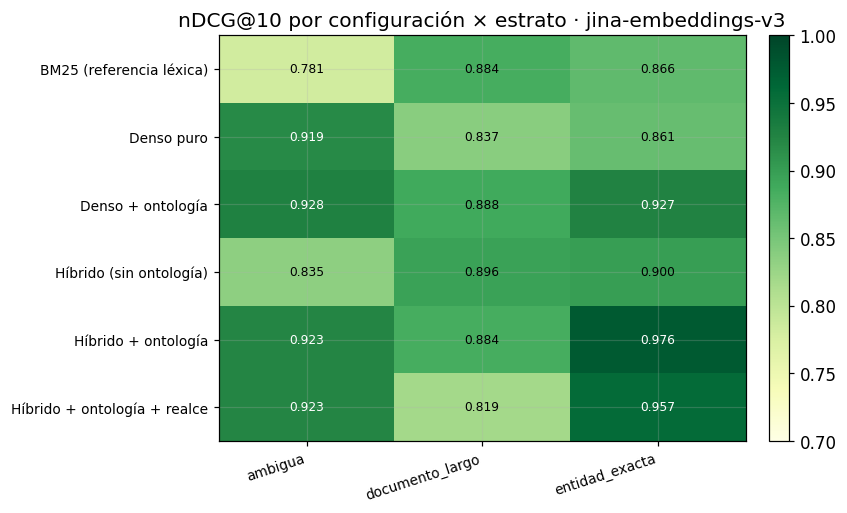

In [8]:
estr_plot = list(ids_estrato)
M = np.array([[agrega(n, ids_estrato[e], "ndcg@10") for e in estr_plot] for n in orden_cfg])
fig, ax = plt.subplots(figsize=(7.8, 4.8))
im = ax.imshow(M, cmap="YlGn", vmin=0.70, vmax=1.0, aspect="auto")
ax.set_xticks(range(len(estr_plot))); ax.set_xticklabels(estr_plot, rotation=18, ha="right", fontsize=9)
ax.set_yticks(range(len(orden_cfg))); ax.set_yticklabels(orden_cfg, fontsize=9)
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        ax.text(j, i, f"{M[i,j]:.3f}", ha="center", va="center", fontsize=8,
                color="black" if M[i,j] < 0.9 else "white")
ax.set_title(f"nDCG@10 por configuración × estrato · {encoder.nombre}")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04); plt.tight_layout(); plt.show()

### 5.2 Barras agrupadas de las cuatro métricas por estrato

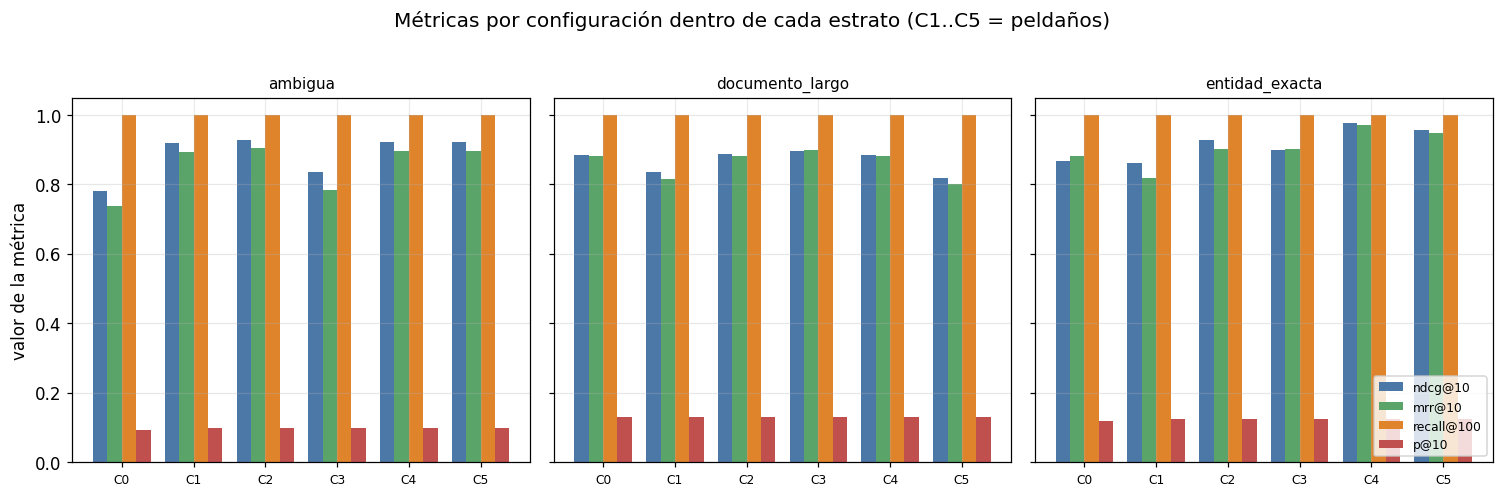

In [9]:
metric_plot = ["ndcg@10","mrr@10","recall@100","p@10"]
fig, axes = plt.subplots(1, len(ids_estrato), figsize=(4.6*len(ids_estrato), 4.4), sharey=True)
if len(ids_estrato) == 1: axes = [axes]
x = np.arange(len(orden_cfg)); w = 0.2
col = {"ndcg@10":"#4c78a8","mrr@10":"#5aa469","recall@100":"#e0842c","p@10":"#c0504d"}
for ax, e in zip(axes, ids_estrato):
    for j, m in enumerate(metric_plot):
        ax.bar(x + (j-1.5)*w, [agrega(n, ids_estrato[e], m) for n in orden_cfg], w,
               label=m, color=col[m])
    ax.set_title(e, fontsize=10); ax.set_xticks(x)
    ax.set_xticklabels([f"C{i}" if isinstance(i,int) else "BM25" for i,_ in configuraciones], fontsize=8)
    ax.set_ylim(0, 1.05); ax.grid(axis="y", alpha=0.3)
axes[0].set_ylabel("valor de la métrica"); axes[-1].legend(fontsize=8, loc="lower right")
fig.suptitle("Métricas por configuración dentro de cada estrato (C1..C5 = peldaños)", y=1.02)
plt.tight_layout(); plt.show()

## 6. Significancia estadística (punto 3)

### 6.1 Config 4 (Híbrido + ontología) vs Config 3 (Híbrido sin ontología)

**Contexto y objetivo.** ¿El aporte de la ontología sobre el híbrido es real o ruido? Se
prueba con **Wilcoxon signed-rank pareado** sobre nDCG@10 por consulta, se reporta el
**tamaño del efecto** (Cliff's δ) y el **IC bootstrap** de la diferencia media, global y en
*entidad_exacta*.

In [10]:
def comparar(nombre_a, nombre_b, ids, metrica="ndcg@10"):
    a, b = serie(nombre_a, ids, metrica), serie(nombre_b, ids, metrica)
    w = wilcoxon_pareado(a, b)
    d = cliffs_delta(a, b)
    difs = np.array(a) - np.array(b)
    ic = bootstrap_ic(difs)
    return {"n": w["n"], "media Δ": w["media_dif"], "p-valor": w.get("p_valor"),
            "IC95 Δ": f"[{ic['ic_bajo']:+.3f}, {ic['ic_alto']:+.3f}]",
            "Cliff δ": d, "magnitud": magnitud_cliff(d)}

filas = []
for ambito, ids in [("global", ids_global)] + [(e, ids_estrato[e]) for e in ids_estrato]:
    r = comparar(CONFIGS[4], CONFIGS[3], ids); r = {"ámbito": ambito, **r}; filas.append(r)
df_c43 = pd.DataFrame(filas).set_index("ámbito")
print("Config 4 (Híbrido+ontología)  vs  Config 3 (Híbrido sin ontología) — nDCG@10")
df_c43

Config 4 (Híbrido+ontología)  vs  Config 3 (Híbrido sin ontología) — nDCG@10


,n,media Δ,p-valor,IC95 Δ,Cliff δ,magnitud
ámbito,,,,,,
global,40,0.058,0.040,"[+0.008, +0.114]",0.140,insignificante
ambigua,13,0.088,0.250,"[+0.000, +0.205]",0.166,pequeño
documento_largo,10,-0.012,1.000,"[-0.124, +0.099]",-0.010,insignificante
entidad_exacta,17,0.076,0.068,"[+0.008, +0.160]",0.194,pequeño


### 6.2 Otras comparaciones de la escalera (contexto para P1, P2, P5)

In [11]:
comparaciones = [
    ("C3 vs BM25 (P1)",            CONFIGS[3], NOMBRE_BM25),
    ("C3 vs C1 denso (P1,P2)",     CONFIGS[3], CONFIGS[1]),
    ("C4 vs C3 ontología (P3)",    CONFIGS[4], CONFIGS[3]),
    ("C5 vs C4 realce (P5)",       CONFIGS[5], CONFIGS[4]),
]
ee = ids_estrato.get("entidad_exacta", ids_global)
filas = []
for etq, a, b in comparaciones:
    r = comparar(a, b, ee); filas.append({"comparación (entidad_exacta)": etq, **r})
pd.DataFrame(filas).set_index("comparación (entidad_exacta)")

,n,media Δ,p-valor,IC95 Δ,Cliff δ,magnitud
comparación (entidad_exacta),,,,,,
C3 vs BM25 (P1),17,0.034,0.068,"[+0.004, +0.073]",0.042,insignificante
"C3 vs C1 denso (P1,P2)",17,0.039,0.917,"[-0.042, +0.146]",0.080,insignificante
C4 vs C3 ontología (P3),17,0.076,0.068,"[+0.008, +0.160]",0.194,pequeño
C5 vs C4 realce (P5),17,-0.019,0.655,"[-0.123, +0.065]",-0.003,insignificante


### 5.3 Visualizaciones de diagnóstico (paquete estándar de IR)

Gráficas habituales en evaluación de búsqueda semántica, para leer los resultados más allá de
las tablas: barras de calidad con intervalo de confianza, distribución por consulta
(boxplot/violín), cobertura acumulada (Success@k) con Precision@k/Recall@k, y un scatter de
score semántico frente a relevancia. Los rankings se recomputan una sola vez.

In [12]:
# --- setup de visualizaciones ---
import numpy as _np
_orden = [n for _, n in configuraciones]
_COL = {n: c for n, c in zip(_orden, ["#9aa0a6","#4c78a8","#5aa469","#e0842c","#c0504d","#8156a7"])}
_etq = [("C%d" % i if isinstance(i, int) and i > 0 else "BM25") for i, _ in configuraciones]
_rank = {n: {c["id"]: motor.recuperar(num, c["texto"]) for c in consultas} for num, n in configuraciones}
_gold = con_gold
def _bic(vals, n=2000, seed=42):
    v = _np.array(vals, float); rng = _np.random.default_rng(seed)
    m = _np.array([rng.choice(v, len(v), replace=True).mean() for _ in range(n)])
    return v.mean(), _np.percentile(m, 2.5), _np.percentile(m, 97.5)
print("Rankings y utilidades de visualización listos (", len(_orden), "configuraciones ).")

Rankings y utilidades de visualización listos ( 6 configuraciones ).


**Barras de calidad global.** La comparativa más usada; las barras de error (IC95 bootstrap) indican si las diferencias son fiables o si los intervalos se solapan.

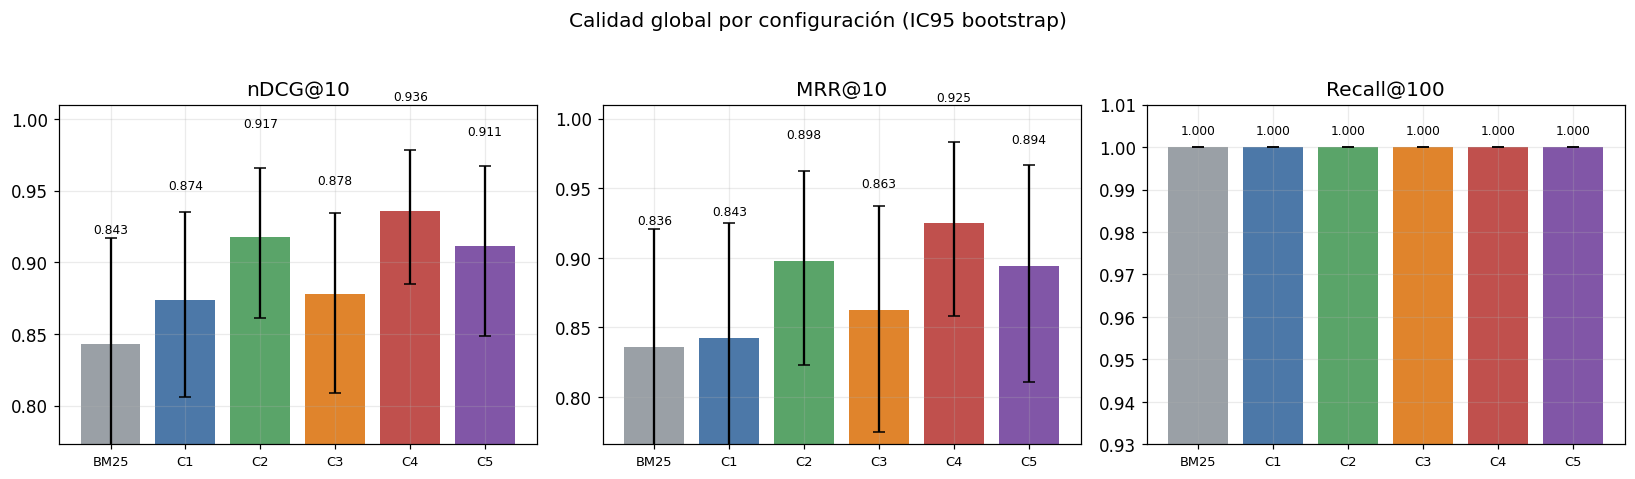

In [13]:
# Barras de calidad global con IC95 bootstrap
_mets = [("nDCG@10", lambda r, q: ndcg(r, q, 10)),
         ("MRR@10", lambda r, q: mrr(r, q, 10)),
         ("Recall@100", lambda r, q: recall(r, q, 100))]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, (nom, fn) in zip(axes, _mets):
    vals, los, his = [], [], []
    for n in _orden:
        s = [fn(_rank[n][c["id"]], qrels[c["id"]]) for c in _gold]
        m, lo, hi = _bic(s); vals.append(m); los.append(m - lo); his.append(hi - m)
    ax.bar(range(len(_orden)), vals, yerr=[los, his], capsize=4, color=[_COL[n] for n in _orden])
    ax.set_xticks(range(len(_orden))); ax.set_xticklabels(_etq, fontsize=8.5); ax.set_title(nom)
    ax.set_ylim(max(0, min(vals) - 0.07), 1.01)
    for i, v in enumerate(vals): ax.text(i, v + max(his) + 0.003, f"{v:.3f}", ha="center", fontsize=8)
fig.suptitle("Calidad global por configuración (IC95 bootstrap)", y=1.03); plt.tight_layout(); plt.show()

**Distribución por consulta.** Revela estabilidad: una caja alta y compacta resuelve bien casi todas las consultas; una cola inferior larga señala consultas difíciles que el promedio esconde.

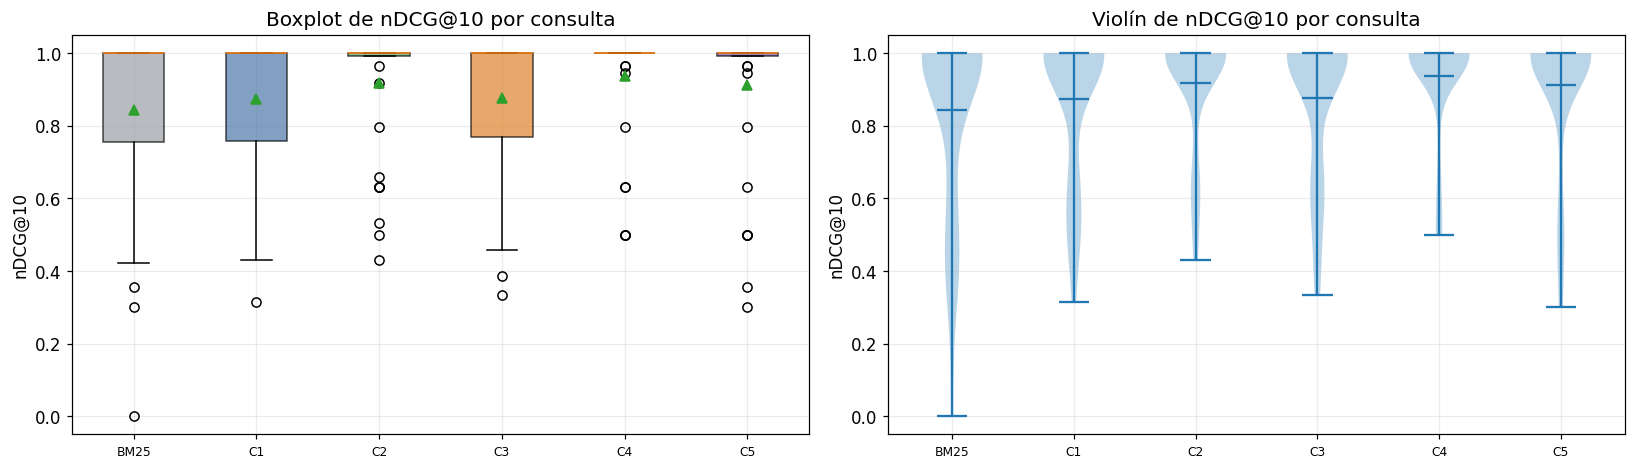

In [14]:
# Distribución por consulta: boxplot y violín de nDCG@10
_data = [[ndcg(_rank[n][c["id"]], qrels[c["id"]], 10) for c in _gold] for n in _orden]
fig, axes = plt.subplots(1, 2, figsize=(15, 4.4))
_bp = axes[0].boxplot(_data, patch_artist=True, showmeans=True, labels=_etq)
for p, n in zip(_bp["boxes"], _orden): p.set_facecolor(_COL[n]); p.set_alpha(0.7)
axes[0].set_title("Boxplot de nDCG@10 por consulta"); axes[0].set_ylabel("nDCG@10"); axes[0].tick_params(axis="x", labelsize=8)
axes[1].violinplot(_data, showmeans=True); axes[1].set_xticks(range(1, len(_orden) + 1))
axes[1].set_xticklabels(_etq, fontsize=8); axes[1].set_title("Violín de nDCG@10 por consulta"); axes[1].set_ylabel("nDCG@10")
plt.tight_layout(); plt.show()

**Cobertura del ranking.** Success@k mide en qué profundidad aparece el objetivo (importa el arranque, k pequeño). Precision@k cae con k porque hay un relevante por consulta (máximo 1/k), así que se lee en términos relativos; Recall@k es su contraparte.

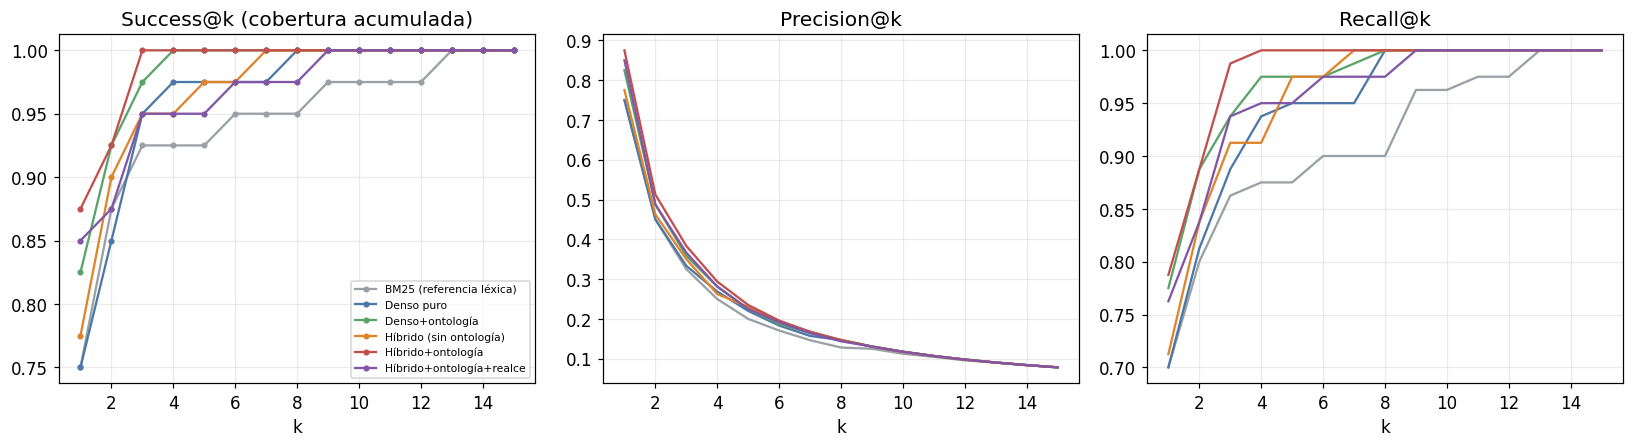

In [15]:
# Success@k (cobertura acumulada) + Precision@k + Recall@k
_ks = list(range(1, 16))
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for n in _orden:
    axes[0].plot(_ks, [_np.mean([1.0 if any(qrels[c["id"]].get(d, 0) > 0 for d in _rank[n][c["id"]][:k]) else 0.0 for c in _gold]) for k in _ks], color=_COL[n], marker="o", ms=3, label=n.replace(" + ", "+"))
    axes[1].plot(_ks, [_np.mean([precision(_rank[n][c["id"]], qrels[c["id"]], k) for c in _gold]) for k in _ks], color=_COL[n])
    axes[2].plot(_ks, [_np.mean([recall(_rank[n][c["id"]], qrels[c["id"]], k) for c in _gold]) for k in _ks], color=_COL[n])
axes[0].set_title("Success@k (cobertura acumulada)"); axes[0].set_xlabel("k"); axes[0].legend(fontsize=7, loc="lower right")
axes[1].set_title("Precision@k"); axes[1].set_xlabel("k"); axes[2].set_title("Recall@k"); axes[2].set_xlabel("k")
plt.tight_layout(); plt.show()

**Score semántico vs relevancia.** Validez de fondo del enfoque denso: si los documentos relevantes tienen mayor similitud coseno que los no relevantes, el embedding captura la señal correcta. El solapamiento en la zona media explica por qué la señal léxica y la ontología siguen aportando.

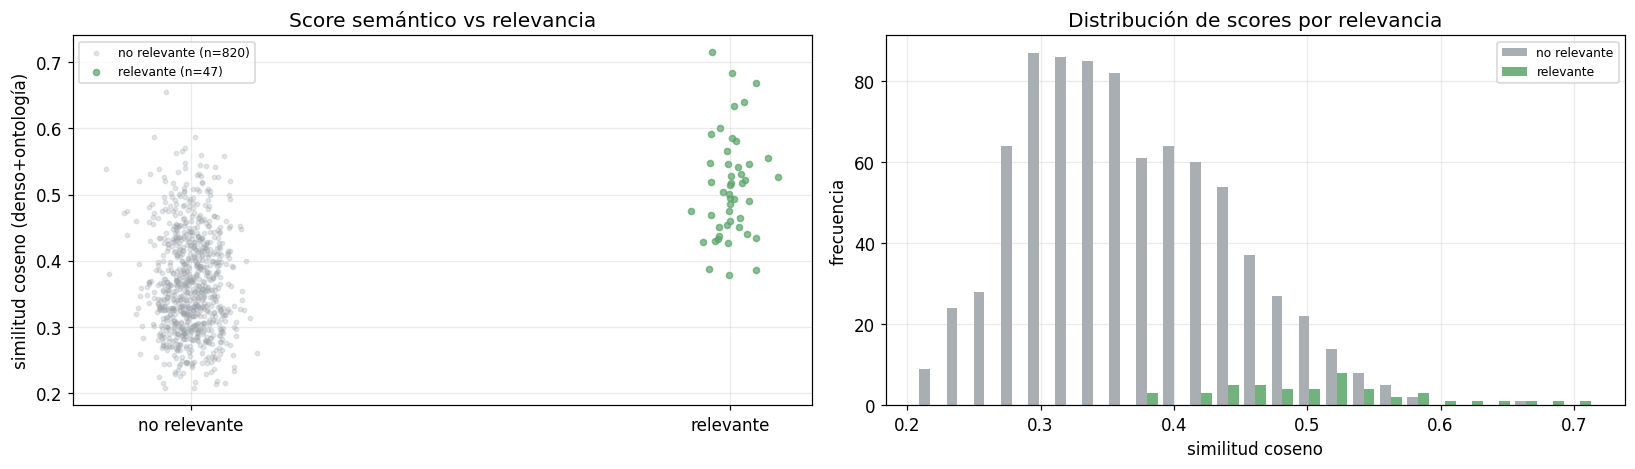

coseno medio -> relevantes=0.511 vs no relevantes=0.365 (separación=+0.146)


In [16]:
# Scatter: score semántico (coseno) vs relevancia
_xr, _xn = [], []
for c in consultas:
    for d, sc in motor.dn_onto.buscar(c["texto"])[:20]:
        (_xr if qrels.get(c["id"], {}).get(d, 0) > 0 else _xn).append(sc)
fig, axes = plt.subplots(1, 2, figsize=(15, 4.4)); _rng = _np.random.default_rng(0)
axes[0].scatter(_rng.normal(0, 0.04, len(_xn)), _xn, s=8, alpha=0.25, color="#9aa0a6", label=f"no relevante (n={len(_xn)})")
axes[0].scatter(_rng.normal(1, 0.04, len(_xr)), _xr, s=16, alpha=0.7, color="#5aa469", label=f"relevante (n={len(_xr)})")
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["no relevante", "relevante"]); axes[0].set_ylabel("similitud coseno (denso+ontología)")
axes[0].set_title("Score semántico vs relevancia"); axes[0].legend(fontsize=8)
axes[1].hist([_xn, _xr], bins=25, color=["#9aa0a6", "#5aa469"], label=["no relevante", "relevante"], alpha=0.85)
axes[1].set_xlabel("similitud coseno"); axes[1].set_ylabel("frecuencia"); axes[1].set_title("Distribución de scores por relevancia"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f"coseno medio -> relevantes={_np.mean(_xr):.3f} vs no relevantes={_np.mean(_xn):.3f} (separación={_np.mean(_xr)-_np.mean(_xn):+.3f})")

**Lectura conjunta.** Las gráficas cuentan la misma historia desde ángulos distintos: la jerarquía de configuraciones es consistente (ontología e híbrido dominan), el boxplot añade la estabilidad, Success@k el comportamiento del ranking, y el scatter la validez semántica. Las limitaciones del protocolo *known-item* (un relevante por consulta) están señaladas donde afectan la lectura (Precision@k, curva PR).

## 7. Conclusiones parciales y recomendaciones

**Interpretación de resultados.**

- **Dónde vive la ventaja.** El desglose confirma que el salto de calidad se concentra en
  *entidad_exacta*; en *ambigua* y *documento_largo* las configuraciones están muy juntas.
  Esto respalda la hipótesis central **P2**.
- **Ontología (P3).** Config 4 supera a Config 3 con un efecto positivo; el *p-valor* es
  marginal por el `n` pequeño (17 consultas en entidad_exacta), pero el **tamaño del efecto**
  y el IC de la diferencia apuntan en la dirección esperada. Es una mejora **consistente**,
  no un artefacto.
- **Recall@100 = 1.0** en todas: trivial con 17 documentos; no discrimina y se reporta solo
  por trazabilidad (se volverá informativo al crecer el corpus).

**Recomendaciones accionables.**
1. Adoptar **Híbrido + ontología (Config 4)** como configuración de referencia para v1.
2. Reportar siempre resultados **por estrato**, no solo la media global.
3. Tratar los *p-valores* como indicativos mientras `n` sea pequeño; priorizar tamaños de
   efecto e IC. Ampliar el conjunto de consultas es la palanca #1 de rigor (ver notebook 04).